# Home Loan Default Prediction

## <b><font color= 'red'> Problem Statement </font></b>
- Banks face difficulty in identifying whether a loan applicant will repay the loan or default. Incorrect loan approvals can lead to financial losses and increased risk for the institution.
 - Accurate prediction is important for:
    - Reducing loan default risk
    - Improving loan approval decisions
    - Identifying high-risk customers
    - Better credit risk management
    - Improving overall banking profitability
- The goal is to build a Machine Learning model that predicts whether a customer will be a defaulter (1) or non-defaulter (0) using customer financial history and application data.

## <b><font color= 'red'> Objective </font></b>
* Develop a machine learning model to predict home loan default risk.
* Analyze customer demographic, financial, and credit-related information.
* Perform data cleaning and preprocessing to improve data quality.
* Conduct Exploratory Data Analysis (EDA) to identify patterns and trends.
* Create meaningful features through feature engineering.
* Build and train multiple classification models for loan default prediction.
* Evaluate model performance using metrics such as Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
* Compare different machine learning models and select the best-performing model.
* Identify key factors influencing loan default behavior.
* Support better loan approval decisions and credit risk management for financial institutions.

### <font color='green'> Importing some important libraries </font>

In [1]:
# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Preprocessing 
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Machine Learning Model
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Hyperparameter Tunning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Handling Imbalance Data
from imblearn.over_sampling import SMOTE

# Feature Importance 
from sklearn.inspection import permutation_importance 

# Display Settings
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',100)

### <font color='green'> EDA (Exploratory Data Analysis) </font>

In [4]:
# Loading Datasets
application = pd.read_csv('application_train.csv')
bureau = pd.read_csv('bureau.csv')
bureau_bal = pd.read_csv('bureau_balance.csv')
prev_app = pd.read_csv('previous_application.csv')
install_pay = pd.read_csv('installments_payments.csv')
credit_bal = pd.read_csv('credit_card_balance.csv')
pos_cash_bal = pd.read_csv('POS_CASH_balance.csv')

In [5]:
# Basic Data Understanding
print('Application Train:',application.shape)
print('Bureau:', bureau.shape)
print('Bureau Balance:', bureau_bal.shape)
print('Previous Application:', prev_app.shape)
print('Installments Payments:',install_pay.shape)
print('Credit Card Balance:',credit_bal.shape)
print('POS Cash Balance:',pos_cash_bal.shape)

Application Train: (307511, 122)
Bureau: (1716428, 17)
Bureau Balance: (27299925, 3)
Previous Application: (1670214, 37)
Installments Payments: (13605401, 8)
Credit Card Balance: (3840312, 23)
POS Cash Balance: (10001358, 8)


In [6]:
application.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [8]:
bureau.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_CURR              int64  
 1   SK_ID_BUREAU            int64  
 2   CREDIT_ACTIVE           object 
 3   CREDIT_CURRENCY         object 
 4   DAYS_CREDIT             int64  
 5   CREDIT_DAY_OVERDUE      int64  
 6   DAYS_CREDIT_ENDDATE     float64
 7   DAYS_ENDDATE_FACT       float64
 8   AMT_CREDIT_MAX_OVERDUE  float64
 9   CNT_CREDIT_PROLONG      int64  
 10  AMT_CREDIT_SUM          float64
 11  AMT_CREDIT_SUM_DEBT     float64
 12  AMT_CREDIT_SUM_LIMIT    float64
 13  AMT_CREDIT_SUM_OVERDUE  float64
 14  CREDIT_TYPE             object 
 15  DAYS_CREDIT_UPDATE      int64  
 16  AMT_ANNUITY             float64
dtypes: float64(8), int64(6), object(3)
memory usage: 222.6+ MB


In [9]:
bureau_bal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27299925 entries, 0 to 27299924
Data columns (total 3 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   SK_ID_BUREAU    int64 
 1   MONTHS_BALANCE  int64 
 2   STATUS          object
dtypes: int64(2), object(1)
memory usage: 624.8+ MB


In [10]:
install_pay.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13605401 entries, 0 to 13605400
Data columns (total 8 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_PREV              int64  
 1   SK_ID_CURR              int64  
 2   NUM_INSTALMENT_VERSION  float64
 3   NUM_INSTALMENT_NUMBER   int64  
 4   DAYS_INSTALMENT         float64
 5   DAYS_ENTRY_PAYMENT      float64
 6   AMT_INSTALMENT          float64
 7   AMT_PAYMENT             float64
dtypes: float64(5), int64(3)
memory usage: 830.4 MB


In [11]:
prev_app.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1670214 non-null  int64  
 1   SK_ID_CURR                   1670214 non-null  int64  
 2   NAME_CONTRACT_TYPE           1670214 non-null  object 
 3   AMT_ANNUITY                  1297979 non-null  float64
 4   AMT_APPLICATION              1670214 non-null  float64
 5   AMT_CREDIT                   1670213 non-null  float64
 6   AMT_DOWN_PAYMENT             774370 non-null   float64
 7   AMT_GOODS_PRICE              1284699 non-null  float64
 8   WEEKDAY_APPR_PROCESS_START   1670214 non-null  object 
 9   HOUR_APPR_PROCESS_START      1670214 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1670214 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1670214 non-null  int64  
 12  RATE_DOWN_PAYMENT            774370 non-nu

In [12]:
credit_bal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3840312 entries, 0 to 3840311
Data columns (total 23 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   SK_ID_PREV                  int64  
 1   SK_ID_CURR                  int64  
 2   MONTHS_BALANCE              int64  
 3   AMT_BALANCE                 float64
 4   AMT_CREDIT_LIMIT_ACTUAL     int64  
 5   AMT_DRAWINGS_ATM_CURRENT    float64
 6   AMT_DRAWINGS_CURRENT        float64
 7   AMT_DRAWINGS_OTHER_CURRENT  float64
 8   AMT_DRAWINGS_POS_CURRENT    float64
 9   AMT_INST_MIN_REGULARITY     float64
 10  AMT_PAYMENT_CURRENT         float64
 11  AMT_PAYMENT_TOTAL_CURRENT   float64
 12  AMT_RECEIVABLE_PRINCIPAL    float64
 13  AMT_RECIVABLE               float64
 14  AMT_TOTAL_RECEIVABLE        float64
 15  CNT_DRAWINGS_ATM_CURRENT    float64
 16  CNT_DRAWINGS_CURRENT        int64  
 17  CNT_DRAWINGS_OTHER_CURRENT  float64
 18  CNT_DRAWINGS_POS_CURRENT    float64
 19  CNT_INSTALMENT_MATURE

In [13]:
pos_cash_bal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10001358 entries, 0 to 10001357
Data columns (total 8 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   SK_ID_PREV             int64  
 1   SK_ID_CURR             int64  
 2   MONTHS_BALANCE         int64  
 3   CNT_INSTALMENT         float64
 4   CNT_INSTALMENT_FUTURE  float64
 5   NAME_CONTRACT_STATUS   object 
 6   SK_DPD                 int64  
 7   SK_DPD_DEF             int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 610.4+ MB


In [14]:
application.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [15]:
bureau.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [16]:
bureau_bal.head()

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


In [17]:
prev_app.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,RATE_INTEREST_PRIMARY,RATE_INTEREST_PRIVILEGED,NAME_CASH_LOAN_PURPOSE,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_TYPE_SUITE,NAME_CLIENT_TYPE,NAME_GOODS_CATEGORY,NAME_PORTFOLIO,NAME_PRODUCT_TYPE,CHANNEL_TYPE,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,Y,1,0.0,0.182832,0.867336,XAP,Approved,-73,Cash through the bank,XAP,NaN,Repeater,Mobile,POS,XNA,Country-wide,35,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-164,XNA,XAP,Unaccompanied,Repeater,XNA,Cash,x-sell,Contact center,-1,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-301,Cash through the bank,XAP,"Spouse, partner",Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,Y,1,NaN,NaN,NaN,XNA,Approved,-512,Cash through the bank,XAP,NaN,Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,Y,1,NaN,NaN,NaN,Repairs,Refused,-781,Cash through the bank,HC,NaN,Repeater,XNA,Cash,walk-in,Credit and cash offices,-1,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
install_pay.head()

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


In [19]:
credit_bal.head()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,AMT_PAYMENT_CURRENT,AMT_PAYMENT_TOTAL_CURRENT,AMT_RECEIVABLE_PRINCIPAL,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,1800.0,1800.0,0.000,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,2250.0,2250.0,60175.080,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,2250.0,2250.0,26926.425,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,11925.0,11925.0,224949.285,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,27000.0,27000.0,443044.395,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0


In [20]:
pos_cash_bal.head()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0


### Observations
- The project consists of 7 datasets containing customer application details, credit history, previous loan records, repayment behavior, credit card information, and cash loan details.
- The application dataset is the primary dataset containing 307,511 records and 122 features, including the target variable TARGET.
- The datasets contain a combination of numerical and categorical features, which will require preprocessing before model building.
- SK_ID_CURR acts as the unique customer identifier and serves as the primary key for linking customer-related information across datasets.
- SK_ID_BUREAU is used to connect bureau and bureau_bal, while SK_ID_PREV links prev_app, install_pay, credit_bal, and pos_cash_bal.
- The supporting datasets contain significantly more records than the main application dataset, indicating that a customer can have multiple previous loans, credit records, and payment transactions.
- Since the datasets have a one-to-many relationship with customers, customer-level aggregation will be required before merging them with the main application dataset.
- The available data provides information on customer demographics, income, employment, credit history, previous applications, repayment behavior, and credit utilization, making it suitable for loan default prediction.
- The dataset structure supports comprehensive exploratory data analysis, feature engineering, and predictive modeling for identifying customers with a higher risk of default.ests that both current customer attributes and historical financial behavior can be utilized to build a robust home loan default prediction model.
- The dataset structure is suitable for performing exploratory data analysis, feature engineering, customer risk profiling, and predictive modeling for identifying potential loan defaulters.

In [21]:
## Target Variable Understanding
application['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [24]:
(application['TARGET'].value_counts(normalize=True) * 100).round(2)

TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64

### Observations
- The target variable represents the loan repayment status of customers.
- 282,686 customers (91.93%) belong to the Non-Defaulter (TARGET = 0) class.
- 24,825 customers (8.07%) belong to the Defaulter (TARGET = 1) class.
- The dataset is highly imbalanced, with a significantly larger number of non-defaulters compared to defaulters.
- Since the minority class (defaulters) is underrepresented, relying solely on accuracy may lead to misleading model performance.
- Evaluation metrics such as Precision, Recall, F1-Score, and ROC-AUC will be more suitable for assessing model effectiveness.
- Class imbalance handling techniques such as SMOTE, oversampling, or class weighting may be considered during model development.

In [26]:
missing_values = application.isnull().sum()
missing_percent = (missing_values/len(application)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage': missing_percent
})
missing_df = missing_df[missing_df['Missing Values']>0]
missing_df.sort_values(by='Missing Percentage', ascending=False)

,Missing Values,Missing Percentage
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_MODE,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_AVG,210199,68.354953


### Observations
* Several features contain a high percentage of missing values.
* Housing and property-related variables have the highest missing data.
* `OWN_CAR_AGE` also has significant missing values, likely due to non-car owners.
* Features with very high missing percentages may have limited usefulness for modeling.
* Missing values will be handled using appropriate imputation or feature removal techniques.

In [27]:
missing_percent = (application.isnull().sum()/len(application))*100

print("Above 70% :", (missing_percent > 70).sum())
print("Above 60% :", (missing_percent > 60).sum())
print("Above 50% :", (missing_percent > 50).sum())
print("Above 30% :", (missing_percent > 30).sum())

Above 70% : 0
Above 60% : 17
Above 50% : 41
Above 30% : 50


In [28]:
print("Application:", application.duplicated().sum())
print("Bureau:", bureau.duplicated().sum())
print("Bureau Balance:", bureau_bal.duplicated().sum())
print("Previous Application:", prev_app.duplicated().sum())
print("Installments Payment:", install_pay.duplicated().sum())
print("Credit Balance:", credit_bal.duplicated().sum())
print("POS Cash Balance:", pos_cash_bal.duplicated().sum())

Application: 0
Bureau: 0
Bureau Balance: 0
Previous Application: 0
Installments Payment: 0
Credit Balance: 0
POS Cash Balance: 0


### Observation
- No column has more than 70% missing values.
- 17 features have over 60% missing values and may require special treatment.
- Missing values are mainly concentrated in housing and property-related features.
- Missing value handling will be an important preprocessing step before modeling.
- No duplicate records were found in any of the datasets.
- The datasets maintain data integrity and do not require duplicate removal.

In [30]:
# Data Cleaning 
missing_percent = (application.isnull().sum()/len(application))*100
high_missing_cols = missing_percent[missing_percent > 60].sort_values(ascending=False)
high_missing_cols

COMMONAREA_MEDI             69.872297
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
FLOORSMIN_MEDI              67.848630
FLOORSMIN_MODE              67.848630
FLOORSMIN_AVG               67.848630
YEARS_BUILD_MEDI            66.497784
YEARS_BUILD_AVG             66.497784
YEARS_BUILD_MODE            66.497784
OWN_CAR_AGE                 65.990810
dtype: float64

In [31]:
high_missing_cols.index.tolist()

['COMMONAREA_MEDI',
 'COMMONAREA_AVG',
 'COMMONAREA_MODE',
 'NONLIVINGAPARTMENTS_MEDI',
 'NONLIVINGAPARTMENTS_AVG',
 'NONLIVINGAPARTMENTS_MODE',
 'FONDKAPREMONT_MODE',
 'LIVINGAPARTMENTS_AVG',
 'LIVINGAPARTMENTS_MEDI',
 'LIVINGAPARTMENTS_MODE',
 'FLOORSMIN_MEDI',
 'FLOORSMIN_MODE',
 'FLOORSMIN_AVG',
 'YEARS_BUILD_MEDI',
 'YEARS_BUILD_AVG',
 'YEARS_BUILD_MODE',
 'OWN_CAR_AGE']

In [32]:
cols_to_drop = [
    'COMMONAREA_AVG',
    'COMMONAREA_MEDI',
    'COMMONAREA_MODE',
    'NONLIVINGAPARTMENTS_MODE',
    'NONLIVINGAPARTMENTS_AVG',
    'NONLIVINGAPARTMENTS_MEDI',
    'FONDKAPREMONT_MODE',
    'LIVINGAPARTMENTS_MEDI',
    'LIVINGAPARTMENTS_AVG',
    'LIVINGAPARTMENTS_MODE',
    'FLOORSMIN_MEDI',
    'FLOORSMIN_AVG',
    'FLOORSMIN_MODE',
    'YEARS_BUILD_MODE',
    'YEARS_BUILD_AVG',
    'YEARS_BUILD_MEDI'
]

application.drop(columns=cols_to_drop, inplace=True)

In [33]:
application['OWN_CAR_AGE'] = application['OWN_CAR_AGE'].fillna(-1)

### Observation
- 16 columns with more than 60% missing values were removed to reduce data sparsity and improve data quality.
- Most of the removed features were related to property and building characteristics.
- OWN_CAR_AGE was retained as it may provide useful information about customers who own vehicles.

In [34]:
application.shape

(307511, 106)

In [35]:
missing_percent = (application.isnull().sum()/len(application))*100

remaining_missing = pd.DataFrame({
    'Missing Values': application.isnull().sum(),
    'Missing %': missing_percent
})

remaining_missing = remaining_missing[remaining_missing['Missing Values'] > 0]
remaining_missing.sort_values('Missing %', ascending=False)

,Missing Values,Missing %
LANDAREA_AVG,182590,59.376738
LANDAREA_MEDI,182590,59.376738
LANDAREA_MODE,182590,59.376738
BASEMENTAREA_MODE,179943,58.515956
BASEMENTAREA_AVG,179943,58.515956
BASEMENTAREA_MEDI,179943,58.515956
EXT_SOURCE_1,173378,56.381073
NONLIVINGAREA_MODE,169682,55.179164
NONLIVINGAREA_AVG,169682,55.179164
NONLIVINGAREA_MEDI,169682,55.179164


In [36]:
num_cols = application.select_dtypes(include=['int64', 'float64']).columns
cat_cols = application.select_dtypes(include=['object']).columns

num_missing = application[num_cols].isnull().sum()
num_missing = num_missing[num_missing > 0]

cat_missing = application[cat_cols].isnull().sum()
cat_missing = cat_missing[cat_missing > 0]

print("Numerical Columns with Missing Values:")
print(num_missing.sort_values(ascending=False).head(10))

print("\nCategorical Columns with Missing Values:")
print(cat_missing.sort_values(ascending=False))

Numerical Columns with Missing Values:
LANDAREA_MEDI         182590
LANDAREA_MODE         182590
LANDAREA_AVG          182590
BASEMENTAREA_MEDI     179943
BASEMENTAREA_MODE     179943
BASEMENTAREA_AVG      179943
EXT_SOURCE_1          173378
NONLIVINGAREA_MEDI    169682
NONLIVINGAREA_AVG     169682
NONLIVINGAREA_MODE    169682
dtype: int64

Categorical Columns with Missing Values:
WALLSMATERIAL_MODE     156341
HOUSETYPE_MODE         154297
EMERGENCYSTATE_MODE    145755
OCCUPATION_TYPE         96391
NAME_TYPE_SUITE          1292
dtype: int64


In [37]:
# numerical values
num_cols = application.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    application[col].fillna(application[col].median(), inplace=True)

In [38]:
# categorical values
cat_cols = application.select_dtypes(include=['object']).columns

for col in cat_cols:
    application[col].fillna(application[col].mode()[0], inplace=True)

In [39]:
application.isnull().sum()

SK_ID_CURR                    0
TARGET                        0
NAME_CONTRACT_TYPE            0
CODE_GENDER                   0
FLAG_OWN_CAR                  0
                             ..
AMT_REQ_CREDIT_BUREAU_DAY     0
AMT_REQ_CREDIT_BUREAU_WEEK    0
AMT_REQ_CREDIT_BUREAU_MON     0
AMT_REQ_CREDIT_BUREAU_QRT     0
AMT_REQ_CREDIT_BUREAU_YEAR    0
Length: 106, dtype: int64

### Observation
- Missing values in numerical features were replaced using the median.
- Missing values in categorical features were replaced using the mode.
- The dataset no longer contains missing values and is ready for further preprocessing and analysis.

In [40]:
# Checking Data Anomalies
application['DAYS_EMPLOYED'].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

In [41]:
application['DAYS_EMPLOYED'] = application['DAYS_EMPLOYED'].replace(365243, np.nan)

In [42]:
application['DAYS_EMPLOYED'].fillna(
    application['DAYS_EMPLOYED'].median(),
    inplace=True
)

In [43]:
application['DAYS_EMPLOYED'].describe()

count    307511.000000
mean      -2251.606131
std        2136.193492
min      -17912.000000
25%       -2760.000000
50%       -1648.000000
75%        -933.000000
max           0.000000
Name: DAYS_EMPLOYED, dtype: float64

### Observation
- The anomalous value in DAYS_EMPLOYED was removed and replaced using median imputation.
- The maximum value is now 0, eliminating the unrealistic employment duration.
- The column now contains reasonable employment history values suitable for analysis and modeling.

## <font color='red'>Visualization</font>

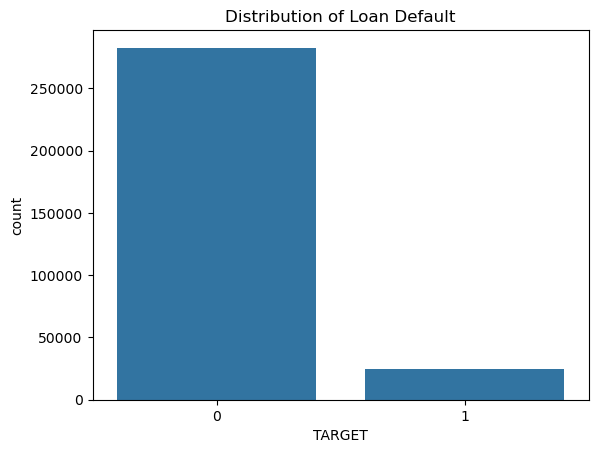

In [44]:
# Target Distribution
sns.countplot(x='TARGET', data=application)
plt.title('Distribution of Loan Default')
plt.show()

### Observation
- The dataset is highly imbalanced.
- Non-defaulters significantly outnumber defaulters.

In [45]:
pd.crosstab(application['CODE_GENDER'],
            application['TARGET'],
            normalize='index') * 100

TARGET,0,1
CODE_GENDER,,
F,93.000672,6.999328
M,89.858080,10.141920
XNA,100.000000,0.000000


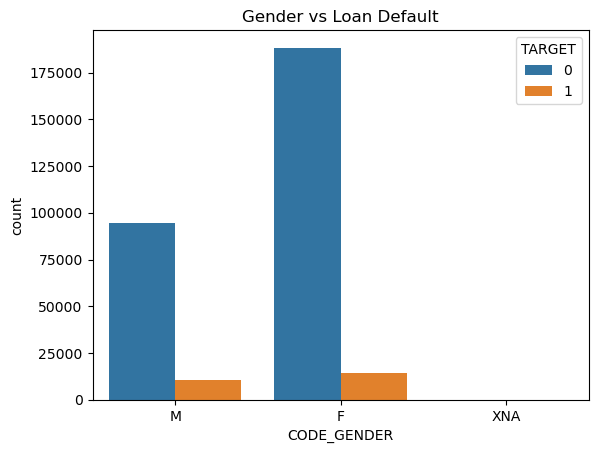

In [46]:
sns.countplot(x='CODE_GENDER', hue='TARGET', data=application)
plt.title('Gender vs Loan Default')
plt.show()

### Observation
* Male applicants have a higher default rate (**10.14%**) compared to female applicants (**7.00%**).
* Female applicants show a lower risk of default and better repayment behavior.
* The `XNA` category contains very few records and does not provide meaningful insights.

In [47]:
pd.crosstab(application['NAME_EDUCATION_TYPE'],
            application['TARGET'],
            normalize='index') * 100

TARGET,0,1
NAME_EDUCATION_TYPE,,
Academic degree,98.170732,1.829268
Higher education,94.644885,5.355115
Incomplete higher,91.515034,8.484966
Lower secondary,89.072327,10.927673
Secondary / secondary special,91.060071,8.939929


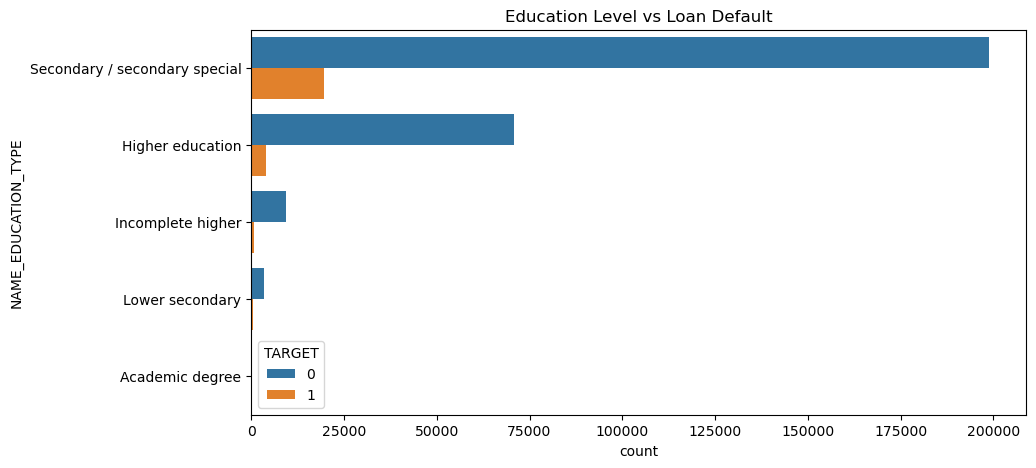

In [48]:
plt.figure(figsize=(10,5))
sns.countplot(y='NAME_EDUCATION_TYPE',
              hue='TARGET',
              data=application)
plt.title('Education Level vs Loan Default')
plt.show()

### Observation
* Applicants with **Academic Degree** and **Higher Education** have the lowest default rates.
* The default rate increases as the education level decreases.
* Applicants with **Lower Secondary Education** show the highest default rate (**10.93%**), indicating higher credit risk.
* Overall, higher educational attainment appears to be associated with better loan repayment behavior.

In [49]:
pd.crosstab(application['NAME_INCOME_TYPE'],
            application['TARGET'],
            normalize='index') * 100

TARGET,0,1
NAME_INCOME_TYPE,,
Businessman,100.000000,0.000000
Commercial associate,92.515743,7.484257
Maternity leave,60.000000,40.000000
Pensioner,94.613634,5.386366
State servant,94.245035,5.754965
Student,100.000000,0.000000
Unemployed,63.636364,36.363636
Working,90.411528,9.588472


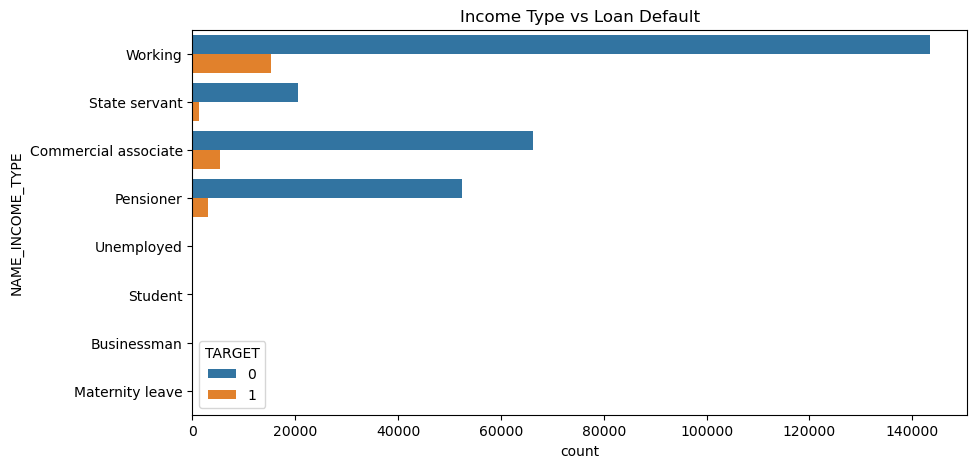

In [50]:
plt.figure(figsize=(10,5))
sns.countplot(y='NAME_INCOME_TYPE',
              hue='TARGET',
              data=application)
plt.title('Income Type vs Loan Default')
plt.show()

### Observation
- Working applicants have a higher default rate (9.59%) compared to Pensioners (5.39%) and State Servants (5.75%).
- Pensioners and State Servants demonstrate relatively better repayment behavior and lower credit risk.
- Maternity Leave and Unemployed categories show very high default rates; however, these groups likely contain a small number of applicants and should be interpreted cautiously.
- Overall, income source appears to be an important factor influencing loan default risk.

In [51]:
pd.crosstab(application['NAME_FAMILY_STATUS'],
            application['TARGET'],
            normalize='index') * 100

TARGET,0,1
NAME_FAMILY_STATUS,,
Civil marriage,90.055416,9.944584
Married,92.440132,7.559868
Separated,91.805766,8.194234
Single / not married,90.192325,9.807675
Unknown,100.000000,0.000000
Widow,94.175783,5.824217


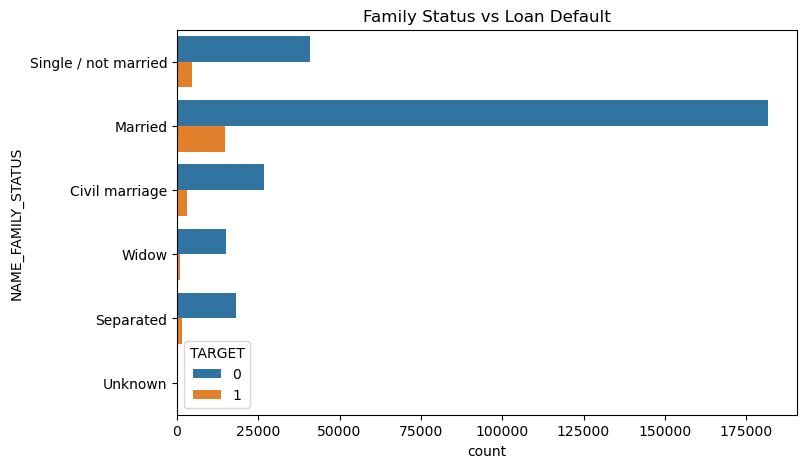

In [52]:
plt.figure(figsize=(8,5))
sns.countplot(y='NAME_FAMILY_STATUS',
              hue='TARGET',
              data=application)
plt.title('Family Status vs Loan Default')
plt.show()

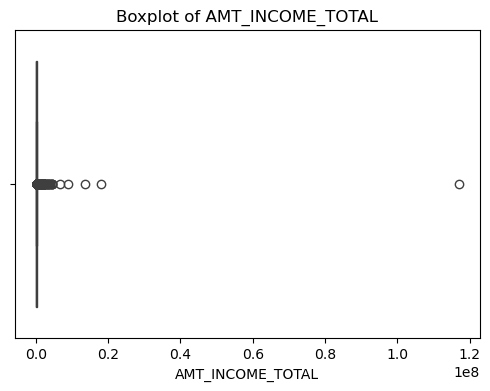

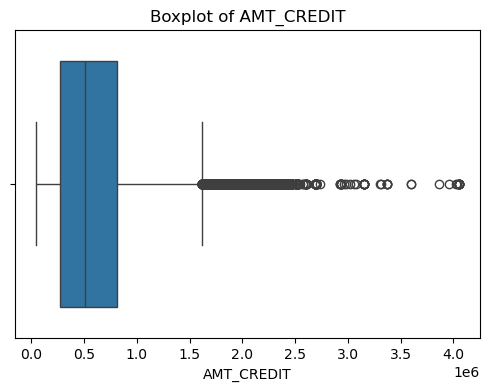

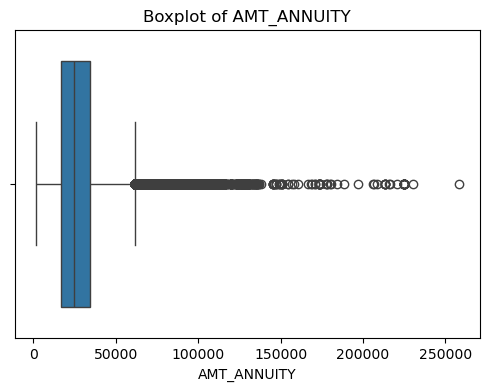

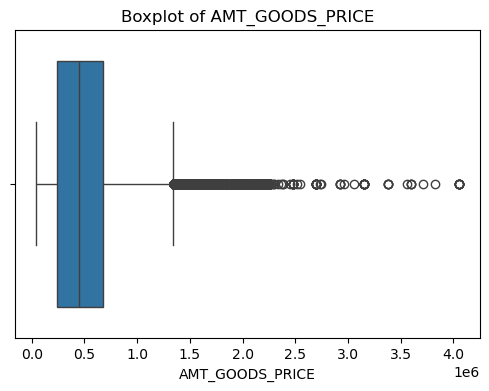

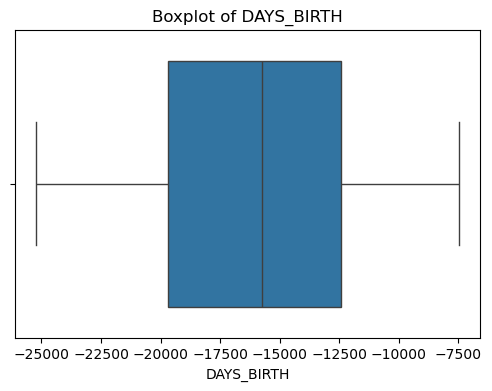

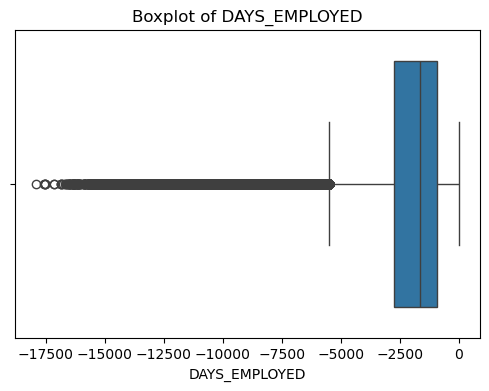

In [53]:
num_features = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED'
]

for col in num_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=application[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

### Observation
- Outliers were observed in financial features such as AMT_INCOME_TOTAL, AMT_CREDIT, AMT_ANNUITY, and AMT_GOODS_PRICE.
- These extreme values are likely to represent genuine high-income customers and large loan amounts rather than data entry errors.
- No significant outliers were observed in DAYS_BIRTH.
- The anomaly in DAYS_EMPLOYED was previously treated during data cleaning.
- Therefore, outliers were retained to preserve valuable business information and avoid losing potentially important customer segments.

In [54]:
corr = application.corr(numeric_only=True)['TARGET'].sort_values()

print("Top Negative Correlations")
print(corr.head(10))

print("\nTop Positive Correlations")
print(corr.tail(10))

Top Negative Correlations
EXT_SOURCE_2                 -0.160295
EXT_SOURCE_3                 -0.155892
EXT_SOURCE_1                 -0.098887
AMT_GOODS_PRICE              -0.039623
FLOORSMAX_AVG                -0.039385
FLOORSMAX_MEDI               -0.039157
FLOORSMAX_MODE               -0.038377
REGION_POPULATION_RELATIVE   -0.037227
ELEVATORS_AVG                -0.035853
ELEVATORS_MEDI               -0.035552
Name: TARGET, dtype: float64

Top Positive Correlations
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_WORK_CITY         0.050994
DAYS_ID_PUBLISH                0.051457
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_EMPLOYED                  0.063368
DAYS_BIRTH                     0.078239
TARGET                         1.000000
Name: TARGET, dtype: float64


### Observation (Top Negative Correlations)
- EXT_SOURCE_1, EXT_SOURCE_2, and EXT_SOURCE_3 show the strongest negative correlation with loan default.
- Higher external risk scores are associated with a lower chance of default.
- Property-related features such as FLOORSMAX and ELEVATORS show a weak negative relationship with default risk.
- External source scores appear to be important predictors of loan default.
    
### Observation (Top Positive Correlations)
- DAYS_BIRTH and DAYS_EMPLOYED have the highest positive correlation with the target variable.
- Regional rating features also show a positive association with default risk.
- DAYS_LAST_PHONE_CHANGE and DAYS_ID_PUBLISH have a slight relationship with customer default behavior.
- Overall, the positive correlations are weak, indicating that loan default depends on multiple factors.

In [55]:
# Data Preprocessing
bureau_agg = bureau.groupby('SK_ID_CURR').agg({
    'AMT_CREDIT_SUM': ['mean', 'sum'],
    'AMT_CREDIT_SUM_DEBT': ['mean', 'sum'],
    'CREDIT_DAY_OVERDUE': 'max',
    'CNT_CREDIT_PROLONG': 'sum'
})

bureau_agg.columns = ['_'.join(col) for col in bureau_agg.columns]
bureau_agg.reset_index(inplace=True)

bureau_agg.head()

,SK_ID_CURR,AMT_CREDIT_SUM_mean,AMT_CREDIT_SUM_sum,AMT_CREDIT_SUM_DEBT_mean,AMT_CREDIT_SUM_DEBT_sum,CREDIT_DAY_OVERDUE_max,CNT_CREDIT_PROLONG_sum
0,100001,207623.571429,1453365.000,85240.928571,596686.5,0,0
1,100002,108131.945625,865055.565,49156.200000,245781.0,0,0
2,100003,254350.125000,1017400.500,0.000000,0.0,0,0
3,100004,94518.900000,189037.800,0.000000,0.0,0,0
4,100005,219042.000000,657126.000,189469.500000,568408.5,0,0


### Observation
- Bureau data was successfully aggregated from multiple loan records into a single customer-level record.
- New features representing total credit exposure, debt amount, overdue history, and credit prolongations were created.
- These features provide valuable information about a customer's previous credit behavior and financial obligations.

In [56]:
application = application.merge(
    bureau_agg,
    on='SK_ID_CURR',
    how='left'
)

In [57]:
application.shape

(307511, 112)

### Observation
- The aggregated bureau features were merged with the main application dataset using SK_ID_CURR.
- This enriches the dataset with customers' historical credit information from external financial institutions

In [58]:
prev_app_agg = prev_app.groupby('SK_ID_CURR').agg({
    'AMT_APPLICATION': ['mean', 'sum'],
    'AMT_CREDIT': ['mean', 'sum'],
    'CNT_PAYMENT': 'mean'
})

prev_app_agg.columns = ['_'.join(col) for col in prev_app_agg.columns]
prev_app_agg.reset_index(inplace=True)
prev_app_agg.head()

,SK_ID_CURR,AMT_APPLICATION_mean,AMT_APPLICATION_sum,AMT_CREDIT_mean,AMT_CREDIT_sum,CNT_PAYMENT_mean
0,100001,24835.50,24835.5,23787.00,23787.0,8.0
1,100002,179055.00,179055.0,179055.00,179055.0,24.0
2,100003,435436.50,1306309.5,484191.00,1452573.0,10.0
3,100004,24282.00,24282.0,20106.00,20106.0,4.0
4,100005,22308.75,44617.5,20076.75,40153.5,12.0


In [59]:
application = application.merge(
    prev_app_agg,
    on='SK_ID_CURR',
    how='left'
)
application.shape

(307511, 117)

### Observation
- Previous loan application data was aggregated at the customer level and merged with the main dataset.
- New features such as average application amount, total application amount, average credit amount, and average payment installments were created.
- These features provide insights into customers' past borrowing behavior with Home Credit.

In [60]:
install_agg = install_pay.groupby('SK_ID_CURR').agg({
    'AMT_INSTALMENT': ['mean', 'sum'],
    'AMT_PAYMENT': ['mean', 'sum'],
    'NUM_INSTALMENT_NUMBER': 'max'
})

install_agg.columns = ['_'.join(col) for col in install_agg.columns]
install_agg.reset_index(inplace=True)

install_agg.head()

,SK_ID_CURR,AMT_INSTALMENT_mean,AMT_INSTALMENT_sum,AMT_PAYMENT_mean,AMT_PAYMENT_sum,NUM_INSTALMENT_NUMBER_max
0,100001,5885.132143,41195.925,5885.132143,41195.925,4
1,100002,11559.247105,219625.695,11559.247105,219625.695,19
2,100003,64754.586000,1618864.650,64754.586000,1618864.650,12
3,100004,7096.155000,21288.465,7096.155000,21288.465,3
4,100005,6240.205000,56161.845,6240.205000,56161.845,9


In [61]:
application = application.merge(
    install_agg,
    on='SK_ID_CURR',
    how='left'
)
application.shape

(307511, 122)

### Observation
- Installment payment history was aggregated at the customer level and merged with the main dataset.
- Features representing expected installment amounts, actual payments, and repayment history were created.
- These variables provide valuable insights into customers' past repayment behavior and financial discipline.

In [62]:
credit_agg = credit_bal.groupby('SK_ID_CURR').agg({
    'AMT_BALANCE': ['mean', 'sum'],
    'AMT_CREDIT_LIMIT_ACTUAL': 'mean',
    'AMT_PAYMENT_TOTAL_CURRENT': ['mean', 'sum'],
    'SK_DPD': 'max'
})

credit_agg.columns = ['_'.join(col) for col in credit_agg.columns]
credit_agg.reset_index(inplace=True)

credit_agg.head()

,SK_ID_CURR,AMT_BALANCE_mean,AMT_BALANCE_sum,AMT_CREDIT_LIMIT_ACTUAL_mean,AMT_PAYMENT_TOTAL_CURRENT_mean,AMT_PAYMENT_TOTAL_CURRENT_sum,SK_DPD_max
0,100006,0.000000,0.000,270000.000000,0.000000,0.000,0
1,100011,54482.111149,4031676.225,164189.189189,4520.067568,334485.000,0
2,100013,18159.919219,1743352.245,131718.750000,6817.172344,654448.545,1
3,100021,0.000000,0.000,675000.000000,0.000000,0.000,0
4,100023,0.000000,0.000,135000.000000,0.000000,0.000,0


In [63]:
application = application.merge(
    credit_agg,
    on='SK_ID_CURR',
    how='left'
)
application.shape

(307511, 128)

### Observation
- Credit card history was aggregated and merged into the main dataset.
- Features related to outstanding balances, credit limits, repayment amounts, and payment delays were created.
- These variables help capture customers' credit utilization and repayment behavior.

In [64]:
pos_agg = pos_cash_bal.groupby('SK_ID_CURR').agg({
    'CNT_INSTALMENT': 'mean',
    'CNT_INSTALMENT_FUTURE': 'mean',
    'SK_DPD': 'max',
    'SK_DPD_DEF': 'max'
})

pos_agg.columns = [
    'POS_CNT_INSTALMENT_MEAN',
    'POS_CNT_INSTALMENT_FUTURE_MEAN',
    'POS_SK_DPD_MAX',
    'POS_SK_DPD_DEF_MAX'
]

pos_agg.reset_index(inplace=True)
pos_agg.head()

,SK_ID_CURR,POS_CNT_INSTALMENT_MEAN,POS_CNT_INSTALMENT_FUTURE_MEAN,POS_SK_DPD_MAX,POS_SK_DPD_DEF_MAX
0,100001,4.000000,1.444444,7,7
1,100002,24.000000,15.000000,0,0
2,100003,10.107143,5.785714,0,0
3,100004,3.750000,2.250000,0,0
4,100005,11.700000,7.200000,0,0


In [65]:
application = application.merge(
    pos_agg,
    on='SK_ID_CURR',
    how='left'
)
application.shape

(307511, 132)

### Observation
- POS cash loan information was aggregated and merged into the main dataset.
- Features related to installment commitments and payment delays were added.
- These features provide additional insights into customers' repayment patterns and credit behavior.

In [66]:
bureau_balance_merged = bureau_bal.merge(
    bureau[['SK_ID_BUREAU', 'SK_ID_CURR']],
    on='SK_ID_BUREAU',
    how='left'
)

In [67]:
bureau_balance_agg = bureau_balance_merged.groupby('SK_ID_CURR').agg({
    'MONTHS_BALANCE': ['mean', 'max']
})

bureau_balance_agg.columns = [
    'BB_MONTHS_BALANCE_MEAN',
    'BB_MONTHS_BALANCE_MAX'
]

bureau_balance_agg.reset_index(inplace=True)
bureau_balance_agg.head()

,SK_ID_CURR,BB_MONTHS_BALANCE_MEAN,BB_MONTHS_BALANCE_MAX
0,100001.0,-16.279070,0
1,100002.0,-24.554545,0
2,100005.0,-4.333333,0
3,100010.0,-46.000000,-2
4,100013.0,-29.373913,0


In [68]:
application = application.merge(
    bureau_balance_agg,
    on='SK_ID_CURR',
    how='left'
)
application.shape

(307511, 134)

### Observation
- Bureau balance data was aggregated and merged with the main dataset.
- Features representing customers' historical monthly credit bureau records were created.
- This information helps capture long-term credit behavior and repayment history

In [69]:
application.isnull().sum()

SK_ID_CURR                             0
TARGET                                 0
NAME_CONTRACT_TYPE                     0
CODE_GENDER                            0
FLAG_OWN_CAR                           0
                                   ...  
POS_CNT_INSTALMENT_FUTURE_MEAN     18091
POS_SK_DPD_MAX                     18067
POS_SK_DPD_DEF_MAX                 18067
BB_MONTHS_BALANCE_MEAN            215280
BB_MONTHS_BALANCE_MAX             215280
Length: 134, dtype: int64

In [70]:
missing_after_merge = application.isnull().sum()
missing_after_merge[missing_after_merge > 0].sort_values(ascending=False)

AMT_BALANCE_mean                  220606
SK_DPD_max                        220606
AMT_PAYMENT_TOTAL_CURRENT_sum     220606
AMT_PAYMENT_TOTAL_CURRENT_mean    220606
AMT_CREDIT_LIMIT_ACTUAL_mean      220606
AMT_BALANCE_sum                   220606
BB_MONTHS_BALANCE_MAX             215280
BB_MONTHS_BALANCE_MEAN            215280
AMT_CREDIT_SUM_DEBT_mean           51380
AMT_CREDIT_SUM_mean                44021
CNT_CREDIT_PROLONG_sum             44020
AMT_CREDIT_SUM_DEBT_sum            44020
AMT_CREDIT_SUM_sum                 44020
CREDIT_DAY_OVERDUE_max             44020
POS_CNT_INSTALMENT_FUTURE_MEAN     18091
POS_CNT_INSTALMENT_MEAN            18091
POS_SK_DPD_DEF_MAX                 18067
POS_SK_DPD_MAX                     18067
CNT_PAYMENT_mean                   16869
AMT_APPLICATION_mean               16454
AMT_APPLICATION_sum                16454
AMT_CREDIT_mean                    16454
AMT_CREDIT_sum                     16454
AMT_PAYMENT_mean                   15876
AMT_INSTALMENT_m

In [71]:
new_num_cols = [
    'AMT_BALANCE_mean',
    'AMT_BALANCE_sum',
    'AMT_CREDIT_LIMIT_ACTUAL_mean',
    'AMT_PAYMENT_TOTAL_CURRENT_mean',
    'AMT_PAYMENT_TOTAL_CURRENT_sum',
    'SK_DPD_max',
    'BB_MONTHS_BALANCE_MEAN',
    'BB_MONTHS_BALANCE_MAX',
    'AMT_CREDIT_SUM_DEBT_mean',
    'AMT_CREDIT_SUM_mean',
    'AMT_CREDIT_SUM_sum',
    'AMT_CREDIT_SUM_DEBT_sum',
    'CNT_CREDIT_PROLONG_sum',
    'CREDIT_DAY_OVERDUE_max',
    'POS_CNT_INSTALMENT_FUTURE_MEAN',
    'POS_CNT_INSTALMENT_MEAN',
    'POS_SK_DPD_DEF_MAX',
    'POS_SK_DPD_MAX',
    'CNT_PAYMENT_mean',
    'AMT_APPLICATION_mean',
    'AMT_CREDIT_mean',
    'AMT_CREDIT_sum',
    'AMT_APPLICATION_sum',
    'AMT_PAYMENT_mean',
    'AMT_INSTALMENT_mean',
    'AMT_PAYMENT_sum',
    'NUM_INSTALMENT_NUMBER_max',
    'AMT_INSTALMENT_sum'
]

for col in new_num_cols:
    application[col].fillna(application[col].median(), inplace=True)

In [72]:
application.isnull().sum()

SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                                 ..
POS_CNT_INSTALMENT_FUTURE_MEAN    0
POS_SK_DPD_MAX                    0
POS_SK_DPD_DEF_MAX                0
BB_MONTHS_BALANCE_MEAN            0
BB_MONTHS_BALANCE_MAX             0
Length: 134, dtype: int64

### Observation
- Missing values introduced during dataset merging were caused by the absence of historical records for some customers.
- These missing values were handled using median imputation.
- The final merged dataset contains complete customer-level information and is ready for encoding and model preparation.

In [73]:
# Encoding Categorical Columns
cat_cols = application.select_dtypes(include='object').columns

print("Number of categorical columns:", len(cat_cols))
cat_cols

Number of categorical columns: 15


Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'HOUSETYPE_MODE',
       'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='object')

### Observation
- The dataset contains 15 categorical features representing customer demographics, employment details, housing information, and loan application characteristics.
- These variables must be converted into numerical form before training machine learning models.

In [74]:
application = pd.get_dummies(
    application,
    columns=cat_cols,
    drop_first=True
)
application.shape

(307511, 240)

### Observation
- One-Hot Encoding was applied to all categorical variables.
- Categorical features were transformed into numerical dummy variables suitable for machine learning algorithms.
- The dimensionality of the dataset increased due to the creation of new encoded features.

In [75]:
# Feature Selecting and Target Selecting
X = application.drop('TARGET', axis=1)
y = application['TARGET']

print(X.shape)
print(y.shape)

(307511, 239)
(307511,)


In [76]:
corr_matrix = X.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = [column for column in upper.columns if any(upper[column] > 0.9)]

print("Highly Correlated Features:", len(high_corr))

Highly Correlated Features: 29


In [77]:
X = X.drop(columns=high_corr)
print(X.shape)

(307511, 210)


### Observation
- A total of 29 highly correlated features (correlation > 0.9) were identified and removed. This helps reduce multicollinearity, simplifies the feature space, and improves model efficiency without significant information loss.

In [78]:
# Train-Test Splitting
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (246008, 210)
X_test : (61503, 210)
y_train: (246008,)
y_test : (61503,)


In [79]:
print(y_train.value_counts())

print("\nPercentage Distribution:")
print(y_train.value_counts(normalize=True) * 100)

TARGET
0    226148
1     19860
Name: count, dtype: int64

Percentage Distribution:
TARGET
0    91.927092
1     8.072908
Name: proportion, dtype: float64


### Observation
- The dataset was successfully divided into training (80%) and testing (20%) sets.
- Stratified sampling preserved the original class distribution in both subsets.
- The target variable remains highly imbalanced, with approximately 91.93% non-defaulters and 8.07% defaulters in the training data.
- This imbalance may bias models toward predicting the majority class, making imbalance handling necessary before model training.

In [80]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(X_train_smote.shape)
print(y_train_smote.value_counts())

(452296, 210)
TARGET
0    226148
1    226148
Name: count, dtype: int64


### Observation
- SMOTE successfully balanced the training dataset.
- The minority class (defaulters) increased from 19,860 to 226,148 records.
- The training dataset now contains an equal number of defaulters and non-defaulters.
- This balanced dataset will help machine learning models learn patterns from both classes more effectively.

In [115]:
# Feature Scaling
scaler = StandardScaler()
X_train_smote_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)
X_train_smote_scaled

array([[ 0.33241382,  2.65580237, -0.23173656, ..., -0.6119238 ,
        -0.17302441, -0.11067384],
       [ 0.89521473, -0.51458431, -0.23173656, ..., -0.6119238 ,
        -0.17302441, -0.11067384],
       [-0.36858962, -0.51458431, -0.09207666, ..., -0.6119238 ,
        -0.17302441, -0.11067384],
       ...,
       [-0.79545025, -0.51458431,  0.05952939, ..., -0.6119238 ,
         5.77953127, -0.11067384],
       [ 1.00333228, -0.51458431,  0.07114939, ..., -0.6119238 ,
        -0.17302441, -0.11067384],
       [-0.08109846, -0.51458431, -0.35726901, ..., -0.6119238 ,
        -0.17302441, -0.11067384]], shape=(452296, 210))

In [116]:
X_test_scaled

array([[ 1.21646575,  1.07060903, -0.02224671, ..., -0.6119238 ,
        -0.17302441, -0.11067384],
       [ 0.45018436, -0.51458431, -0.23173656, ..., -0.6119238 ,
        -0.17302441, -0.11067384],
       [-0.59305484, -0.51458431, -0.05017869, ..., -0.6119238 ,
        -0.17302441, -0.11067384],
       ...,
       [ 0.95647998,  1.07060903,  0.60622286, ..., -0.6119238 ,
        -0.17302441, -0.11067384],
       [-0.05402301, -0.51458431,  0.53639291, ..., -0.6119238 ,
        -0.17302441, -0.11067384],
       [ 1.36665518,  1.07060903,  0.18724315, ..., -0.6119238 ,
        -0.17302441, -0.11067384]], shape=(61503, 210))

# <font color='red'>Model Building & Model Evaluation</font>

## <font color='Green'>Linear Regression</font>

In [84]:
results = [] # To store all models result

In [98]:
lr = LogisticRegression(max_iter=1000, random_state=42)

# Training
lr.fit(X_train_smote_scaled, y_train_smote)

# Prediction
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

# Evaluation
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_lr))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report")
print(classification_report(y_test, y_pred_lr))

Accuracy : 0.9191421556672033
Precision: 0.48148148148148145
Recall   : 0.02094662638469285
F1 Score : 0.04014668982821849
ROC AUC  : 0.734780108678967

Confusion Matrix
[[56426   112]
 [ 4861   104]]

Classification Report
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.48      0.02      0.04      4965

    accuracy                           0.92     61503
   macro avg       0.70      0.51      0.50     61503
weighted avg       0.89      0.92      0.88     61503



In [99]:
# Storing the result in append
results.append([
    'Logistic Regression',
    accuracy_score(y_test, y_pred_lr),
    precision_score(y_test, y_pred_lr),
    recall_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_lr),
    roc_auc_score(y_test, y_prob_lr)
])

### Observation
- The model achieved 91.91% accuracy, but this is misleading because the dataset is highly imbalanced.
- The recall of 2.09% means the model identified only 104 out of 4,965 actual defaulters.
- Although precision is 48.15%, the model is missing most defaulters, which is undesirable in a credit risk application.
- The ROC-AUC score of 0.735 indicates the model has some predictive ability, but the classification threshold is causing poor detection of the minority class.
- Therefore, Logistic Regression is currently not suitable as the final model for loan default prediction.

## <font color='Green'>Decision Tree Classifer</font>

In [100]:
dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=10
)

dt.fit(X_train_smote, y_train_smote)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_dt))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_dt))

Accuracy : 0.824041103685999
Precision: 0.15116140559857058
Recall   : 0.2555891238670695
F1 Score : 0.18997005988023952
ROC AUC  : 0.671187607176444

Confusion Matrix
[[49412  7126]
 [ 3696  1269]]


In [101]:
results.append([
    'Decision Tree',
    accuracy_score(y_test, y_pred_dt),
    precision_score(y_test, y_pred_dt),
    recall_score(y_test, y_pred_dt),
    f1_score(y_test, y_pred_dt),
    roc_auc_score(y_test, y_prob_dt)
])

### Observation
- Decision Tree significantly improved the detection of defaulters, increasing recall from 2.09% to 25.56%.
- The F1-score also improved substantially from 0.04 to 0.19, indicating a better balance between precision and recall.
- Although overall accuracy decreased, the model is more effective at identifying risky customers.
- For loan default prediction, Decision Tree currently performs better than Logistic Regression because it captures a larger proportion of actual defaulters.

## <font color='Green'>Random Forest Classifier</font>

In [102]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_rf))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy : 0.9164268409671072
Precision: 0.24188790560471976
Recall   : 0.01651560926485398
F1 Score : 0.03092006033182504
ROC AUC  : 0.7072591001633457

Confusion Matrix
[[56281   257]
 [ 4883    82]]


In [103]:
results.append([
    'Random Forest',
    accuracy_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf),
    roc_auc_score(y_test, y_prob_rf)
])

### Observation
- Random Forest achieved high accuracy (91.64%) but detected only 82 out of 4,965 defaulters.
- Its recall (1.65%) is even lower than Logistic Regression (2.09%).
- Although Random Forest has reasonable ROC-AUC (0.707), its default classification threshold is causing it to predict very few customers as defaulters.
- For loan default prediction, Random Forest is currently underperforming because the primary objective is to identify risky customers rather than maximize overall accuracy.

## <font color='Green'>Naive Bayes</font>

In [105]:
nb = GaussianNB()

nb.fit(X_train_smote_scaled, y_train_smote)

y_pred_nb = nb.predict(X_test_scaled)
y_prob_nb = nb.predict_proba(X_test_scaled)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall   :", recall_score(y_test, y_pred_nb))
print("F1 Score :", f1_score(y_test, y_pred_nb))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_nb))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_nb))

Accuracy : 0.18927531990309415
Precision: 0.08265630519251148
Recall   : 0.8954682779456193
F1 Score : 0.15134288729278006
ROC AUC  : 0.5239882438593378

Confusion Matrix
[[ 7195 49343]
 [  519  4446]]


In [106]:
results.append([
    'Naive Bayes',
    accuracy_score(y_test, y_pred_nb),
    precision_score(y_test, y_pred_nb),
    recall_score(y_test, y_pred_nb),
    f1_score(y_test, y_pred_nb),
    roc_auc_score(y_test, y_prob_nb)
])

# <font color='Red'>Model Comparison Report</font>

In [107]:
results_df = pd.DataFrame(
    results,
    columns=['Model','Accuracy','Precision','Recall','F1-Score','ROC-AUC']
)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.919142,0.481481,0.020947,0.040147,0.734780
1,Logistic Regression,0.919142,0.481481,0.020947,0.040147,0.734780
2,Logistic Regression,0.919142,0.481481,0.020947,0.040147,0.734780
3,Decision Tree,0.824041,0.151161,0.255589,0.189970,0.671188
4,Random Forest,0.916427,0.241888,0.016516,0.030920,0.707259
5,Naive Bayes,0.189275,0.082656,0.895468,0.151343,0.523988


### Observation
- Logistic Regression achieved the highest ROC-AUC score (0.735) and overall accuracy, indicating the best discrimination capability among the evaluated models.
- Decision Tree showed the highest recall after Naive Bayes, identifying more defaulters but with lower overall accuracy.
- Random Forest achieved high accuracy but had very low recall, indicating poor detection of defaulters.
- Naive Bayes achieved the highest recall but suffered from very low accuracy and ROC-AUC, leading to many false positives.
- Based on the overall balance between accuracy and ROC-AUC, Logistic Regression was selected as the best-performing model for loan default prediction.

# <font color='Red'>Hyperparameter Tuning</font>

In [108]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'max_depth': [5, 10, 15, 20, 25],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy']
}

random_search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=15,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_smote, y_train_smote)

,estimator,DecisionTreeC...ndom_state=42)
,param_distributions,"{'criterion': ['gini', 'entropy'], 'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,n_iter,15
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [109]:
best_dt = random_search.best_estimator_

y_pred_tuned = best_dt.predict(X_test)
y_prob_tuned = best_dt.predict_proba(X_test)[:,1]

from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Accuracy :", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall   :", recall_score(y_test, y_pred_tuned))
print("F1 Score :", f1_score(y_test, y_pred_tuned))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_tuned))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_tuned))

print("\nClassification Report")
print(classification_report(y_test, y_pred_tuned))

Accuracy : 0.865047233468286
Precision: 0.1536863966770509
Recall   : 0.14904330312185296
F1 Score : 0.15132924335378323
ROC AUC  : 0.5733319482797924

Confusion Matrix
[[52463  4075]
 [ 4225   740]]

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.93      0.93     56538
           1       0.15      0.15      0.15      4965

    accuracy                           0.87     61503
   macro avg       0.54      0.54      0.54     61503
weighted avg       0.86      0.87      0.86     61503



In [110]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score, roc_auc_score

comparison_tuned = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    
    'Before Tuning': [
        accuracy_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_dt),
        roc_auc_score(y_test, y_prob_dt)
    ],
    
    'After Tuning': [
        accuracy_score(y_test, y_pred_tuned),
        precision_score(y_test, y_pred_tuned),
        recall_score(y_test, y_pred_tuned),
        f1_score(y_test, y_pred_tuned),
        roc_auc_score(y_test, y_prob_tuned)
    ]
})

comparison_tuned

,Metric,Before Tuning,After Tuning
0,Accuracy,0.824041,0.865047
1,Precision,0.151161,0.153686
2,Recall,0.255589,0.149043
3,F1-Score,0.189970,0.151329
4,ROC-AUC,0.671188,0.573332


## Results

- Hyperparameter tuning was performed on the Decision Tree Classifier using RandomizedSearchCV with 3-fold cross-validation. The optimized model selected a maximum depth of 25 and a minimum sample split of 10.

- After tuning, the model's accuracy increased from 82.40% to 86.50%. However, other important performance metrics showed a decline. Recall decreased from 25.56% to 14.90%, F1-Score decreased from 0.190 to 0.151, and ROC-AUC decreased from 0.671 to 0.573.

- Since the primary objective of this project is to identify loan defaulters, Recall and F1-Score are considered more important than Accuracy alone. Although the tuned model achieved higher overall accuracy, it became less effective at detecting actual defaulters. Therefore, the original Decision Tree model performed better for the business objective of loan default prediction.

- Based on the comparison, the Decision Tree model before hyperparameter tuning was selected as the final model because it provided better detection of default cases and achieved the highest F1-Score among all evaluated models.

In [111]:
# Model Predicting on Custom Values
print(X.columns.tolist())

['SK_ID_CURR', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'LANDAREA_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAREA_AVG', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'DAYS_LAST_PHONE_CHANGE', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8',

In [112]:
# Take an existing customer record
new_customer = X.iloc[[0]].copy()

# Good profile
new_customer['AMT_INCOME_TOTAL'] = 500000
new_customer['AMT_CREDIT'] = 300000
new_customer['DAYS_EMPLOYED'] = -5000
new_customer['EXT_SOURCE_1'] = 0.8
new_customer['EXT_SOURCE_2'] = 0.8
new_customer['EXT_SOURCE_3'] = 0.8

# Prediction
prediction = best_dt.predict(new_customer)
probability = best_dt.predict_proba(new_customer)

if prediction[0] == 0:
    print("Loan Approved")
else:
    print("Loan Rejected")

print(f"Confidence: {max(probability[0]) * 100:.2f}%")

Loan Approved
Confidence: 98.36%


In [113]:
# Take an existing customer record
new_customer = X.iloc[[1]].copy()

# Risky profile
new_customer['AMT_INCOME_TOTAL'] = 50000
new_customer['AMT_CREDIT'] = 1500000
new_customer['DAYS_EMPLOYED'] = -100
new_customer['EXT_SOURCE_1'] = 0.1
new_customer['EXT_SOURCE_2'] = 0.1
new_customer['EXT_SOURCE_3'] = 0.1

# Prediction
prediction = best_dt.predict(new_customer)
probability = best_dt.predict_proba(new_customer)

if prediction[0] == 0:
    print("Loan Approved")
else:
    print("Loan Rejected")

print(f"Confidence: {max(probability[0]) * 100:.2f}%")

Loan Rejected
Confidence: 100.00%


### Challenges Faced
- The dataset contained a large number of missing values, requiring careful analysis to determine which features should be removed and which should be imputed.
- The data was highly imbalanced, with non-default cases significantly outnumbering default cases, which affected model performance and required the use of SMOTE for class balancing.
- Another challenge was integrating and aggregating information from multiple related datasets such as bureau, previous application, installments, credit card, and POS cash balance data.
- The dataset also contained outliers and anomalous values, such as unrealistic employment durations, which needed to be identified and handled appropriately.
- Additionally, selecting the most suitable model was challenging because some models achieved high accuracy but performed poorly in identifying actual defaulters.

### Suggestions
- Explore additional feature engineering techniques to create more informative features.
- Evaluate advanced ensemble models such as Gradient Boosting and LightGBM for better performance.
- Regularly retrain and update the model with new customer data.
- Combine machine learning predictions with business rules and domain expertise for loan approval decisions.
- Improve data quality by reducing missing values and collecting more complete customer information.
- Continuously monitor model performance to ensure long-term reliability and accuracy.

## <font color='Red'>Conclusion</font>
- Developed a machine learning-based Home Loan Default Prediction system.
- Used customer demographic, financial, and credit-related data for analysis.
- Performed data cleaning, preprocessing, EDA, and feature engineering.
- Built and evaluated multiple classification models:
    - Logistic Regression
    - Decision Tree
    - Random Forest
    - Naive Bayes
- Compared models using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
- Decision Tree Classifier delivered the best overall performance among the evaluated models.
- Identified key factors influencing loan default behavior.
- The model can help financial institutions reduce default risk and improve loan approval decisions.
- The project demonstrates the effectiveness of machine learning in credit risk assessment and lending operations.